In [7]:
# Importing neccessary libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import deeplake as dl
import time
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# Loading in Datasets
train_ds = dl.load('hub://activeloop/gtsrb-train')
test_ds = dl.load('hub://activeloop/gtsrb-test')
print(train_ds.summary())
train_shape = train_ds.images[0].shape
print(f"Image Shape: {train_shape}")

Opening dataset in read-only mode as you don't have write permissions.


|

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/gtsrb-train



-

hub://activeloop/gtsrb-train loaded successfully.



...

/

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/gtsrb-test



-

hub://activeloop/gtsrb-test loaded successfully.



Dataset(path='hub://activeloop/gtsrb-train', read_only=True, tensors=['images', 'boxes', 'labels', 'shapes', 'colors'])

 tensor      htype               shape              dtype  compression
 -------    -------             -------            -------  ------- 
 images      image     (39209, 25:225, 25:243, 3)   uint8    jpeg   
  boxes      bbox            (39209, 1, 4)         float32   None   
 labels   class_label          (39209, 1)          uint32    None   
 shapes   class_label          (39209, 1)          uint32    None   
 colors   class_label          (39209, 1)          uint32    None   
None
Image Shape: (26, 26, 3)


In [11]:
# Preprocessing Images
def preprocess_image(image_array):
    tensor = tf.convert_to_tensor(image_array, dtype=tf.float32)
    resized = tf.image.resize(tensor, (26, 26))
    normalized = resized / 255.0
    return normalized.numpy()

# 2. Extract the raw lists from Deep Lake
train_images = train_ds.images.numpy(aslist=True)
train_labels = train_ds.labels.numpy().squeeze()

test_images = test_ds.images.numpy(aslist=True)
test_labels = test_ds.labels.numpy().squeeze()

# 3. Resize and normalize all image arrays
train_images_resized = np.array([preprocess_image(img) for img in train_images])
test_images_resized = np.array([preprocess_image(img) for img in test_images])

# 4. Shuffle Training Data
indices = np.arange(len(train_images_resized))

# Scramble the indices (setting a seed ensures reproducibility)
np.random.seed(42)
np.random.shuffle(indices)

# Reorder the training images and labels simultaneously using the scrambled indices
train_images_resized = train_images_resized[indices]
train_labels = train_labels[indices]

In [26]:
# Creating and Training the Model
def create_train_model(images, labels):
    model = keras.Sequential([
        layers.Input(shape=(26, 26, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(43, activation='softmax')
    ])
    lr_scheduler = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        alpha=0.0)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_scheduler),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',     # Watch the validation loss
        patience=3,             # How many epochs to wait for recovery
        restore_best_weights=True # Rewind the model to its absolute best epoch
    )
    model.fit(images, labels, epochs=25, batch_size=128, validation_split=0.2, callbacks=[early_stopping])
    return model
traffic_sign_model = create_train_model(train_images_resized, train_labels)
print(traffic_sign_model.summary())

Epoch 1/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.4978 - loss: 1.8653 - val_accuracy: 0.5497 - val_loss: 2.4509
Epoch 2/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8475 - loss: 0.5499 - val_accuracy: 0.9162 - val_loss: 0.5590
Epoch 3/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9177 - loss: 0.2972 - val_accuracy: 0.9637 - val_loss: 0.1827
Epoch 4/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9409 - loss: 0.2056 - val_accuracy: 0.9694 - val_loss: 0.1270
Epoch 5/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9541 - loss: 0.1573 - val_accuracy: 0.9792 - val_loss: 0.0923
Epoch 6/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9595 - loss: 0.1334 - val_accuracy: 0.9806 - val_loss: 0.0843
Epoch 7/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9672 - loss: 0.1100 - val_accuracy: 0.9846 - val_loss: 0.0691
Epoch 8/25
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9706 - loss: 0.0980 - val_accu

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 43)             │        34,443 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,018 (523.51 KB)

 Trainable params: 44,651 (174.42 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 89,303 (348.84 KB)

None


In [27]:
# Evaluating Model with Test Data
def evaluate_model(model, images, labels):
    loss, accuracy = model.evaluate(images, labels)
    loss = np.round(loss, 4)
    accuracy = np.round(accuracy, 4) * 100
    print(f"Loss: {loss} Accuracy: {accuracy}")
evaluate_model(traffic_sign_model, test_images_resized, test_labels)

230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9417 - loss: 0.2289
Loss: 0.2289 Accuracy: 94.17


In [28]:
# Evaluating Latency Data
compiled_model = tf.function(traffic_sign_model)

def evaluate_latency(model, images, num_samples=500):
    warmup_images = images[:20]
    measurement_images = images[20:20 + num_samples]
    for image in warmup_images:
        sample = np.expand_dims(image, axis=0)
        _ = model(sample, training=False)
    time_records = []
    for image in measurement_images:
        sample = np.expand_dims(image, axis=0)
        start_time = time.monotonic()
        _ = model(sample, training=False)
        end_time = time.monotonic()
        inference_time = (end_time - start_time) * 1000
        time_records.append(inference_time)
    return time_records
latency_records = evaluate_latency(compiled_model, test_images_resized)

# Statistical Analysis of Latency
print(f"Average Latency: {np.round(np.mean(latency_records), 2)} ms")
print(f"Min Latency: {np.round(np.min(latency_records), 2)} ms")
print(f"Max Latency: {np.round(np.max(latency_records), 2)} ms")
print(f"Standard Deviation: {np.round(np.std(latency_records), 2)} ms")
print(f"Median Latency: {np.round(np.median(latency_records), 2)} ms")

Average Latency: 0.89 ms
Min Latency: 0.58 ms
Max Latency: 3.15 ms
Standard Deviation: 0.37 ms
Median Latency: 0.77 ms


230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


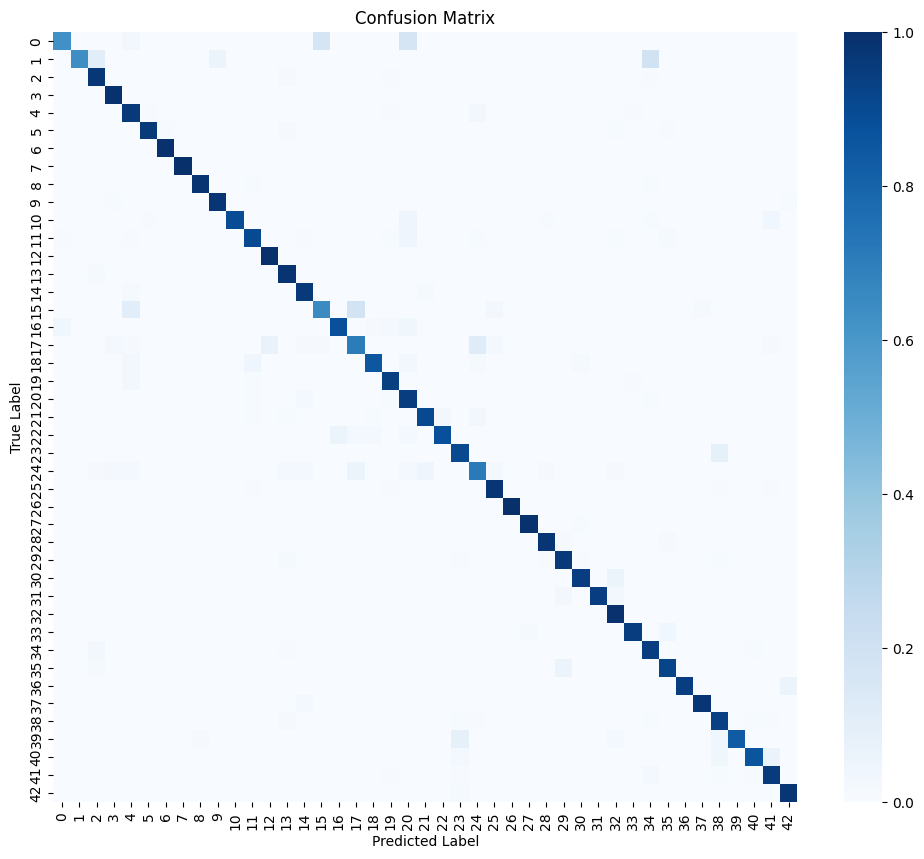

In [29]:
# Confusion Matrix Visualization
y_pred = traffic_sign_model.predict(test_images_resized)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(test_labels, y_pred_classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, annot=False, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()